<a href="https://colab.research.google.com/github/NataliiaFakas/TFG_BMW/blob/main/3_Repetir_estudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tareas pendientes
1.   Revisar GDP 🆗
  * Comprobar que GDP_Growth está en el dataset final
  * Comprobar que no tiene NaN
  * Incluirlo en el modelo de importancia

2.   Revisar Crecimiento demográfico 🆗
  * Eliminar media de población
  * Eliminar columna UE 27

3. Validar países del dataset ❌
    * No especifica en ningún sitio las fuentes del dataset y en el propio dataset pone "Europe" pero no dice qué países está teniendo en cuenta

4. Validar algunas variables macro ❓
  * **ECB deposit rate:** este salió del BCE tal cual: https://www.ecb.europa.eu/stats/policy_and_exchange_rates/key_ecb_interest_rates/html/index.es.html
  * **Euríbor:** Se ha utilizado el Euríbor a 12 meses como indicador de tipos de interés del mercado interbancario europeo. Pero porque se publica diariamente y se ha agregado a nivel anual mediante la media de los valores diarios.
  * **Precio del crudo:** utilizaba medias mensuales acumuladas para sacar la anual.
  
  * **EUR/USD:** era una media anual calculada en base a series mensuales de 365 días

5. Euríbor NaN:🆗 he metido manualmente los valores que faltaban porque eran negativos y no los terminaba de leer bien





# Cargar dataset con todas las variables

En la columna del Euríbor había 7 valores NaN, los cuales eran negativos y no se terminaban de reconocer. Así que los metí manualmente (esto no se ve en el código)

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_variables_macro.csv"
df = pd.read_csv(ruta, sep=';', encoding='latin1')

df.head()


Mounted at /content/drive


,Year,Unemployment_Rate,GDP_Growth,Deposit_facility,HICP,Crec_demog,Prod_Ind,Ventas_Ret,Conf_Cons,Salario_Mes,Precio_crudo,EUR_USD,Euribor
0,2010,13.100000,2.1,1.50,1.62,27978709.91,8.0,0.02,-17.0,1.50,0.29,1.33,1.4
1,2011,13.100000,1.7,2.00,2.70,27943664.50,1.0,0.01,-15.0,2.70,0.40,1.39,1.7
2,2012,14.266667,-1.0,2.50,2.50,27995530.13,-1.0,0.00,-22.0,0.03,0.00,1.29,0.6
3,2013,14.866667,-0.2,3.00,1.35,28029028.13,1.0,0.01,-19.0,0.03,-0.03,1.33,0.4
4,2014,14.200000,1.4,3.25,0.44,28067113.84,2.0,0.01,-12.0,0.03,-0.09,1.33,0.2


In [ ]:
print(df["Euribor"].values) # Nos terminamos de asegurar de que ya no queda ningún NaN

[ 1.4   1.7   0.6   0.4   0.2  -0.05 -0.2  -0.3  -0.3  -0.3  -0.4  -0.5
  2.5   3.9   3.2 ]


También se ha detectado que había una columna UE27 en el crecimiento demográfico para hallar el total. Así que vamos a retirarla. Además había sacado el promedio, en vez de la suma de todos los países para sacar el crecimiento demográfico. Así que ahora sí que es la suma:

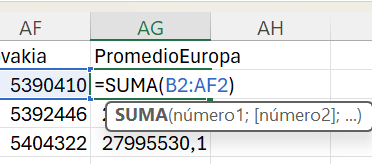

In [ ]:
ruta = "/content/drive/MyDrive/TFG_BMW/datasets/Crecimiento demográfico europa.csv"
df = pd.read_csv(ruta, sep=';', encoding='latin1')

df.head()

,Year,Austria,Belgium,Bulgaria,Switzerland,Cyprus,Czechia,Germany,Denmark,Estonia,...,Malta,Netherlands,Norway,Poland,Portugal,Romania,Sweden,Slovenia,Slovakia,PromedioEuropa
0,2010,8351643,10839905,7421766,7785806,819140,10462088,81802257,5534738,1333290,...,414027,16574989,4858199,38022869,10573479,20294683,9340682,2046976,5390410,454158123
1,2011,8375164,11000638,7369431,7870134,839751,10486731,80222065,5560628,1329660,...,414989,16655799,4920305,38062718,10572721,20199059,9415570,2050189,5392446,453671152
2,2012,8408121,11075889,7327224,7954662,862011,10505445,80327900,5580516,1325217,...,417546,16730348,4985870,38063792,10558950,20095996,9482855,2055496,5404322,454576773
3,2013,8451860,11137974,7202556,8039060,862854,10516125,80523746,5602628,1320174,...,421464,16779575,5051275,38062535,10503889,20020074,9555893,2058821,5410836,455188965
4,2014,8507786,11180840,7117453,8139631,860032,10512419,80767463,5627235,1315819,...,428156,16829289,5109056,38017856,10444092,19947311,9644864,2061085,5415949,455879565


In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

ruta_macro = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_variables_macro.csv"
df = pd.read_csv(ruta_macro, sep=';', encoding='latin1')

ruta_demo = "/content/drive/MyDrive/TFG_BMW/datasets/Crecimiento demográfico europa.csv"
df_demo = pd.read_csv(ruta_demo, sep=';', encoding='latin1')
df_demo = df_demo[["Year", "PromedioEuropa"]]
df = df.drop(columns=["Crec_demog"], errors="ignore")

df = df.merge(df_demo, on="Year", how="left")

df = df.rename(columns={
    "PromedioEuropa": "Crec_demog"
})
df[["Year", "Crec_demog"]].head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Year,Crec_demog
0,2010,454158123
1,2011,453671152
2,2012,454576773
3,2013,455188965
4,2014,455879565


In [ ]:
df = pd.read_csv(ruta_macro, sep=';', encoding='latin1')
df = df.drop(columns=["Crec_demog"], errors="ignore")
df = df.merge(df_demo, on="Year", how="left")
df = df.rename(columns={
    "PromedioEuropa": "Crec_demog"
})
df[["Year", "Crec_demog"]].head()

,Year,Crec_demog
0,2010,454158123
1,2011,453671152
2,2012,454576773
3,2013,455188965
4,2014,455879565


In [ ]:
df.to_csv(ruta, sep=';', index=False, encoding='latin1')



---
# Creación de X e Y


In [ ]:
x = df.drop(columns=["Year"])
print(x.head())

   Unemployment_Rate  GDP_Growth  Deposit_facility  HICP   Crec_demog  \
0          13.100000         2.1              1.50  1.62  27978709.91   
1          13.100000         1.7              2.00  2.70  27943664.50   
2          14.266667        -1.0              2.50  2.50  27995530.13   
3          14.866667        -0.2              3.00  1.35  28029028.13   
4          14.200000         1.4              3.25  0.44  28067113.84   

   Prod_Ind  Ventas_Ret  Conf_Cons  Salario_Mes  Precio_crudo  EUR_USD  \
0       8.0        0.02      -17.0         1.50          0.29     1.33   
1       1.0        0.01      -15.0         2.70          0.40     1.39   
2      -1.0        0.00      -22.0         0.03          0.00     1.29   
3       1.0        0.01      -19.0         0.03         -0.03     1.33   
4       2.0        0.01      -12.0         0.03         -0.09     1.33   

   Euribor  
0      1.4  
1      1.7  
2      0.6  
3      0.4  
4      0.2  


In [ ]:
print(x.shape)

(15, 12)


In [ ]:
ruta_ventas = "/content/drive/MyDrive/TFG_BMW/datasets/BMW_dataset_europe.csv"
df_ventas = pd.read_csv(ruta_ventas, sep=',', encoding='latin1')

df_ventas.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,High
1,i8,2019,Europe,White,Electric,Manual,3.0,35700,96257,4411,Low
2,M5,2011,Europe,Grey,Electric,Automatic,3.3,78042,49507,9383,High
3,i8,2023,Europe,Blue,Diesel,Automatic,3.8,78573,118317,7168,High
4,M3,2014,Europe,Red,Electric,Manual,2.5,74474,65464,9390,High


In [ ]:
y_df = df_ventas.groupby("Year")["Sales_Volume"].sum().reset_index()
y_df = y_df.sort_values("Year").reset_index(drop=True)
y = y_df["Sales_Volume"]
print(y.head())
print(y.shape)


0    2775123
1    2862580
2    2896866
3    2699439
4    2653563
Name: Sales_Volume, dtype: int64
(15,)


In [ ]:
data = df.merge(y_df, on="Year", how="inner")
x = data.drop(columns=["Year", "Sales_Volume"])
y = data["Sales_Volume"]
print(x.shape)
print(y.shape)
print(data[["Year"]])

(15, 12)
(15,)
    Year
0   2010
1   2011
2   2012
3   2013
4   2014
5   2015
6   2016
7   2017
8   2018
9   2019
10  2020
11  2021
12  2022
13  2023
14  2024


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

model = RandomForestRegressor(random_state=42)
model.fit(x, y)

importancias = pd.DataFrame({
    "Variable": x.columns,
    "Importancia": model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print(importancias)

             Variable  Importancia
0   Unemployment_Rate     0.292324
3                HICP     0.158706
9        Precio_crudo     0.132493
4          Crec_demog     0.124309
1          GDP_Growth     0.086280
11            Euribor     0.060417
7           Conf_Cons     0.046333
5            Prod_Ind     0.026976
10            EUR_USD     0.023307
2    Deposit_facility     0.018825
6          Ventas_Ret     0.016433
8         Salario_Mes     0.013597


Se puede observar que las variables más significativas son el Unemployment Rate, seguido del HICP y del precio del crudo y del Crecimiento Demográfico. Porque se alejan más del cero (0,12-0,29).

El GDP Growth, el Euríbor y el Conf_Cons tienen influencia media en el resultado final (0,04-0,08).

Y por último, las faltantes(el EUR/USD, Deposit Facility, Ventas_Ret, Salario_Mes y Prod_Ind) parecen no tener tanto impacto en las ventas de coches de BMW pues se acercan mucho más a cero (0,01-0,02)


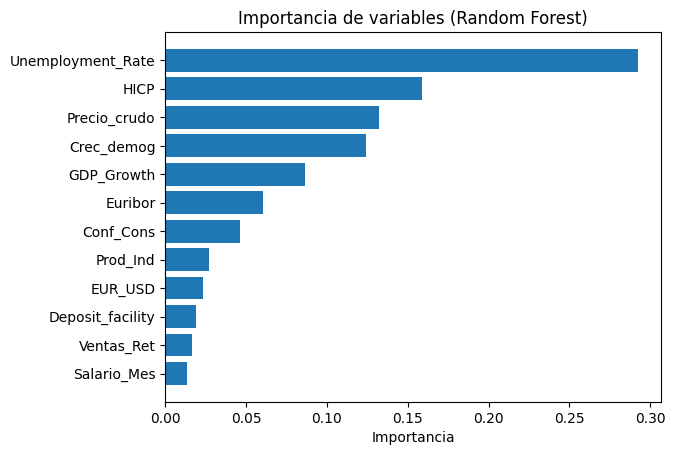

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(importancias["Variable"], importancias["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables (Random Forest)")
plt.xlabel("Importancia")
plt.show()

# Bibliografía
---
Ventas BMW (Kaggle)
* Dataset BMW:https:https://www.kaggle.com/datasets/y0ussefkandil/bmw-sales2010-2024?resource=download
  * Datos 2010-2024

* Notebooks de otras personas sobre este dataset:https://www.kaggle.com/datasets/y0ussefkandil/bmw-sales2010-2024/code
---
Unemployment by sex and age - annual data (eurostat)
* https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Unemployment_statistics

---
Evolución del PIB anual en la eurozona (Datos Macro)

* https://datosmacro.expansion.com/pib/zona-euro
---
Key ECB interest rates (Deposit facility)
* https://www.ecb.europa.eu/stats/policy_and_exchange_rates/key_ecb_interest_rates/html/index.es.html
---
Inflación (HICP Inflation rate - Total - Annual rate of change, Euro area, Monthly)
* https://www.ecb.europa.eu/stats/macroeconomic_and_sectoral/hicp/more/html/data.es.html
---
Population change - Demographic balance and crude rates at national level
* https://ec.europa.eu/eurostat/databrowser/view/demo_gind__custom_17386652/bookmark/table?lang=en&bookmarkId=1c4b8145-a6e5-48a5-afe4-e2b4e983c485&c=1752064755805
---
Evolución anual producción industrial – Eurozona (2010–2024, base 2021=100)
* https://db.nomics.world/Eurostat/teiis080
* https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Long_term_developments_in_industrial_production_-_results_from_short-term_statistics
* https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Industrial_production_%28volume%29_index_overview
* https://ec.europa.eu/eurostat/statistics-explained/index.php?title=National_accounts_and_GDP
* https://www.ceicdata.com/en/indicator/european-union/industrial-production-index-growth
* https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Industrial_production_(volume)_index_overview
---
Evolución anual ventas minoristas – Eurozona (2010–2024, base 2021=100)
* https://www.xtb.com/es/analisis-de-mercado/informe-de-ventas-minoristas-de-la-eurozona
* https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Towards_Digital_Decade_targets_for_Europe
* https://www.ine.es/prensa/icm_prensa.htm
* https://es.tradingeconomics.com/euro-area/retail-sales
---
Evolución anual media tipo de cambio EUR/USD
* https://www.exchange-rates.org/es/historial/usd-eur-2010
* https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-usd.es.html
* https://es.tradingview.com/symbols/EURUSD/
---
Evolución anual petróleo Brent Europa (2009–2026, USD/barril)
* https://www.foronuclear.org/wp-content/uploads/energia2023/cap.4/04.11.htm
* https://es.tradingeconomics.com/commodity/brent-crude-oil
* https://www.epdata.es/evolucion-precio-barril-brent/658dec3a-7f4b-4e92-b79e-fb942048cd2f
---
Euríbor
* https://www.euribordiario.es
* https://www.bancsabadell.com/bsnacional/es/particulares/hipotecas/euribor/
---
Evolución anual compensación por empleado – Eurozona (2010–2024, valores aproximados anuales brutos)
* https://es.tradingeconomics.com/euro-area/wages
---
Confianza del consumidor – Eurozona (2010–2024, saldo en puntos)
* https://tradingeconomics.com/euro-area/consumer-confidence
* https://formatresearch.com/en/2024/09/20/consumer-confidence-eu-and-euro-area-european-commission/

